In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape, df.head()

((1470, 35),
    Age Attrition     BusinessTravel  DailyRate              Department  \
 0   41       Yes      Travel_Rarely       1102                   Sales   
 1   49        No  Travel_Frequently        279  Research & Development   
 2   37       Yes      Travel_Rarely       1373  Research & Development   
 3   33        No  Travel_Frequently       1392  Research & Development   
 4   27        No      Travel_Rarely        591  Research & Development   
 
    DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
 0                 1          2  Life Sciences              1               1   
 1                 8          1  Life Sciences              1               2   
 2                 2          2          Other              1               4   
 3                 3          4  Life Sciences              1               5   
 4                 2          1        Medical              1               7   
 
    ...  RelationshipSatisfaction StandardHours

In [5]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

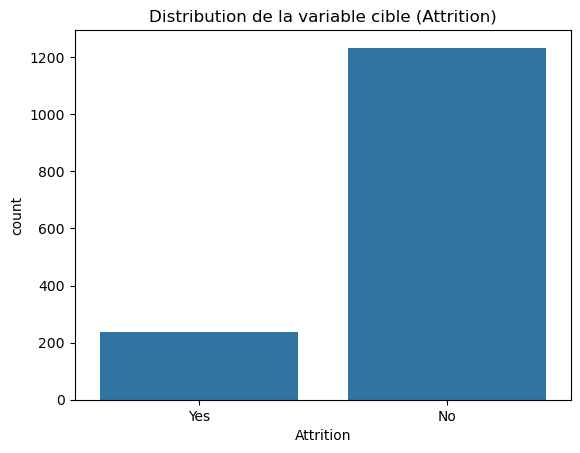

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(data=df, x="Attrition")
ax.set_title("Distribution de la variable cible (Attrition)")
plt.show()

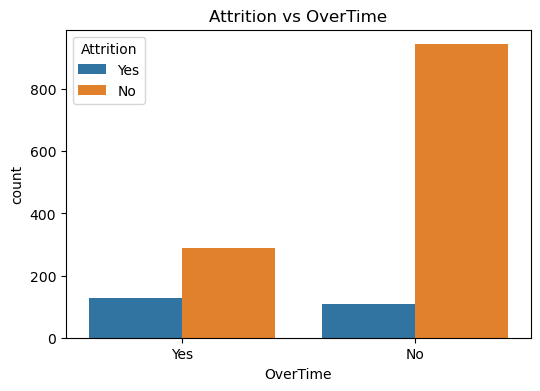

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Attrition vs OverTime")
plt.show()

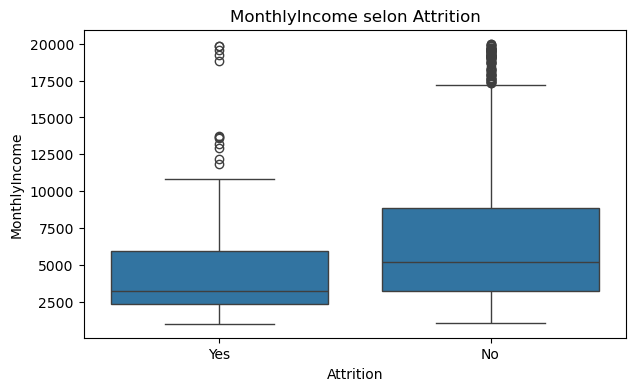

In [9]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("MonthlyIncome selon Attrition")
plt.show()

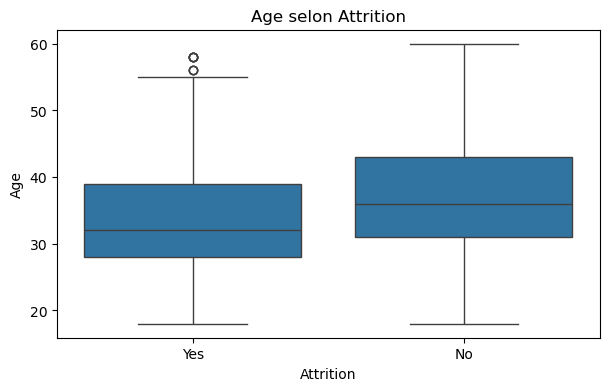

In [10]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Attrition", y="Age")
plt.title("Age selon Attrition")
plt.show()

In [11]:
cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df2 = df.drop(columns=cols_to_drop, errors="ignore")
df2.shape

(1470, 31)

In [12]:
X = df2.drop(columns=["Attrition"])
y = df2["Attrition"].map({"No": 0, "Yes": 1})  # 0/1
y.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((1176, 30), (294, 30))

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Your existing code
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [19]:
# Import the Pipeline class from scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Now we can use Pipeline
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
# Import the necessary module
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
])

tree.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    print("=", name, "=")
    print(classification_report(y_test, y_pred, digits=3))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"Matrice de confusion - {name}")
    plt.show()
    
    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print("ROC-AUC:", round(auc, 3))
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve - {name}")
        plt.show()

= Logistic Regression =
              precision    recall  f1-score   support

           0      0.884     0.960     0.920       247
           1      0.615     0.340     0.438        47

    accuracy                          0.861       294
   macro avg      0.750     0.650     0.679       294
weighted avg      0.841     0.861     0.843       294



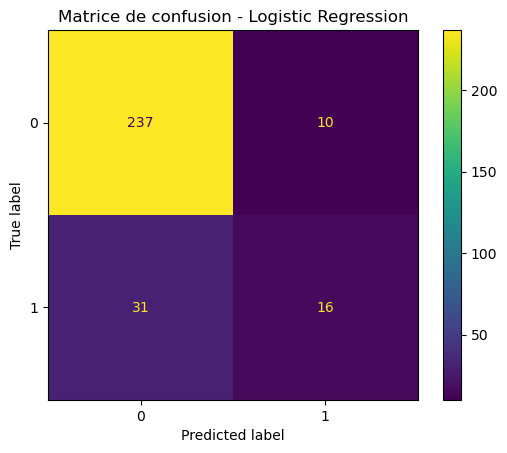

ROC-AUC: 0.812


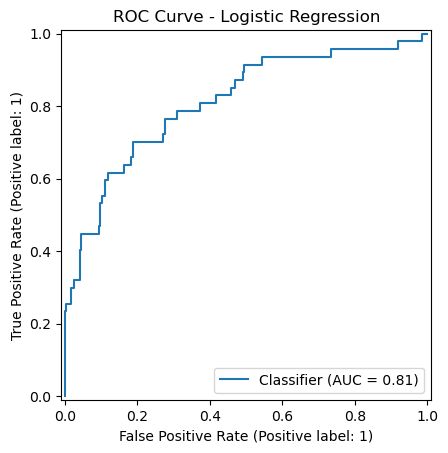

= Decision Tree =
              precision    recall  f1-score   support

           0      0.862     0.960     0.908       247
           1      0.474     0.191     0.273        47

    accuracy                          0.837       294
   macro avg      0.668     0.576     0.590       294
weighted avg      0.800     0.837     0.806       294



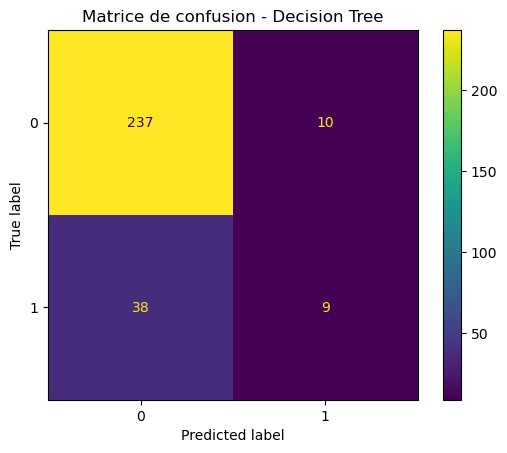

ROC-AUC: 0.662


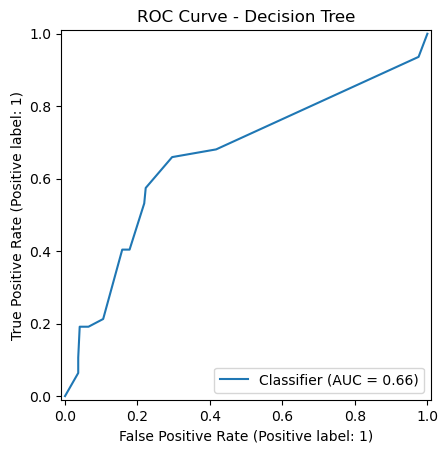

In [28]:
# Import the necessary functions from scikit-learn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay  # Added this import for ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score  # Added this import for roc_auc_score
from sklearn.metrics import RocCurveDisplay  # Added this import for RocCurveDisplay

# Now the evaluate_model function can use classification_report and confusion_matrix
evaluate_model("Logistic Regression", log_reg, X_test, y_test)
evaluate_model("Decision Tree", tree, X_test, y_test)